In [ ]:
# Chạy cell này xong, nhấn 'Restart Session' ở menu Run
!pip install -q --force-reinstall "numpy<2.0.0" "xgboost<3.0.0" "lifelines<0.30.0" "xgbse==0.3.3"

In [2]:
import os
import pandas as pd

base_path = "/kaggle/input/datasets/anhkhang/bich-data/analytical_dataset_with_notes"

print("Nạp dữ liệu từ Kaggle Storage vào RAM...")
df_train = pd.read_parquet(os.path.join(base_path, "split=train"))
df_val = pd.read_parquet(os.path.join(base_path, "split=val"))
df_test = pd.read_parquet(os.path.join(base_path, "split=test"))

print(f"Train: {df_train.shape}")
print(f"Val: {df_val.shape}")
print(f"Test: {df_test.shape}")

Nạp dữ liệu từ Kaggle Storage vào RAM...
Train: (277735, 236)
Val: (58693, 236)
Test: (54837, 236)


In [ ]:
# Kiểm tra danh sách cột và xem thử nội dung note
print(f"Tổng số cột hiện có: {len(df_train.columns)}")
print("-" * 30)

df_train.columns.tolist()

In [31]:
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

def preprocess_data(df, is_train=False, imputer=None):
    df_clean = df.copy()
    
    # 1. Vá lỗi cột gender thành số (0: Nữ, 1: Nam)
    if 'gender' in df_clean.columns:
        df_clean['gender'] = df_clean['gender'].map({'F': 0, 'M': 1, 'Female': 0, 'Male': 1}).fillna(0)
        df_clean['gender'] = pd.to_numeric(df_clean['gender'], errors='coerce')
    
    # 2. CHỌN BÀI TOÁN: Mortality (Tử vong)
    # T là thời gian (duration_days), E là sự kiện tử vong
    T = df_clean['duration_days']
    E = df_clean['event_flag_readmission'] 
    
    # 3. Tách Features (X) 
    # Loại bỏ ID, nhãn mục tiêu và các cột metadata để tránh rò rỉ dữ liệu (Leakage)
    exclude_cols = [
        'hadm_id', 'subject_id', 'duration_days', 
        'event_flag_mortality', 'event_flag_readmission', 
        'split', 'discharge_location_enc', 'admityear'
    ]
    
    feature_cols = [c for c in df_clean.columns if c not in exclude_cols]
    X = df_clean[feature_cols]
    
    # 4. Điền khuyết (Imputation)
    # Lưu ý: Các cột note_emb thường không có NULL, nhưng sinh hiệu (sbp, hr...) thì có rất nhiều
    if is_train:
        imputer = SimpleImputer(strategy='median')
        X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
        return X_imputed, T, E, imputer
    else:
        X_imputed = pd.DataFrame(imputer.transform(X), columns=X.columns)
        return X_imputed, T, E

# THỰC THI PIPELINE
print("--- ĐANG TIỀN XỬ LÝ GOLD DATASET ---")
X_train, T_train, E_train, fitted_imputer = preprocess_data(df_train, is_train=True)
X_val, T_val, E_val = preprocess_data(df_val, is_train=False, imputer=fitted_imputer)
X_test, T_test, E_test = preprocess_data(df_test, is_train=False, imputer=fitted_imputer)

print(f"\n✅ Xử lý xong!")
print(f"-> Tổng số Features đưa vào mô hình: {X_train.shape[1]} cột")
print(f"-> Trong đó bao gồm 128 cột Note Embeddings và các chỉ số sinh hiệu/xét nghiệm.")
print(f"-> Mục tiêu dự báo (Event E): {E_train.name}")

--- ĐANG TIỀN XỬ LÝ GOLD DATASET ---

✅ Xử lý xong!
-> Tổng số Features đưa vào mô hình: 230 cột
-> Trong đó bao gồm 128 cột Note Embeddings và các chỉ số sinh hiệu/xét nghiệm.
-> Mục tiêu dự báo (Event E): event_flag_readmission


In [33]:
from lifelines import CoxPHFitter

print("Đang huấn luyện mô hình Baseline (Cox PH)...")

# Ghép X, T, E của tập Train lại cho lifelines
train_cox_df = X_train.copy()
train_cox_df['T_duration'] = T_train.values
train_cox_df['E_event'] = E_train.values

# Ghép X, T, E của tập Val để đánh giá
val_cox_df = X_val.copy()
val_cox_df['T_duration'] = T_val.values
val_cox_df['E_event'] = E_val.values

# Khởi tạo mô hình (dùng penalizer=0.1 để tránh lỗi ma trận suy biến do dữ liệu y tế phức tạp)
cph = CoxPHFitter(penalizer=0.1)

# Fit mô hình
cph.fit(train_cox_df, duration_col='T_duration', event_col='E_event')

# Đánh giá C-index (Chỉ số C càng gần 1 càng tốt, >0.70 là đạt yêu cầu)
train_c_index = cph.concordance_index_
val_c_index = cph.score(val_cox_df, scoring_method="concordance_index")

print(f"\n[KẾT QUẢ BASELINE]")
print(f"-> C-index trên tập Train: {train_c_index:.4f}")
print(f"-> C-index trên tập Validation: {val_c_index:.4f}")

Đang huấn luyện mô hình Baseline (Cox PH)...

[KẾT QUẢ BASELINE]
-> C-index trên tập Train: 0.7225
-> C-index trên tập Validation: 0.7234


Đang dự đoán và vẽ đường cong chưa tái nhập viện cho 30 ngày...


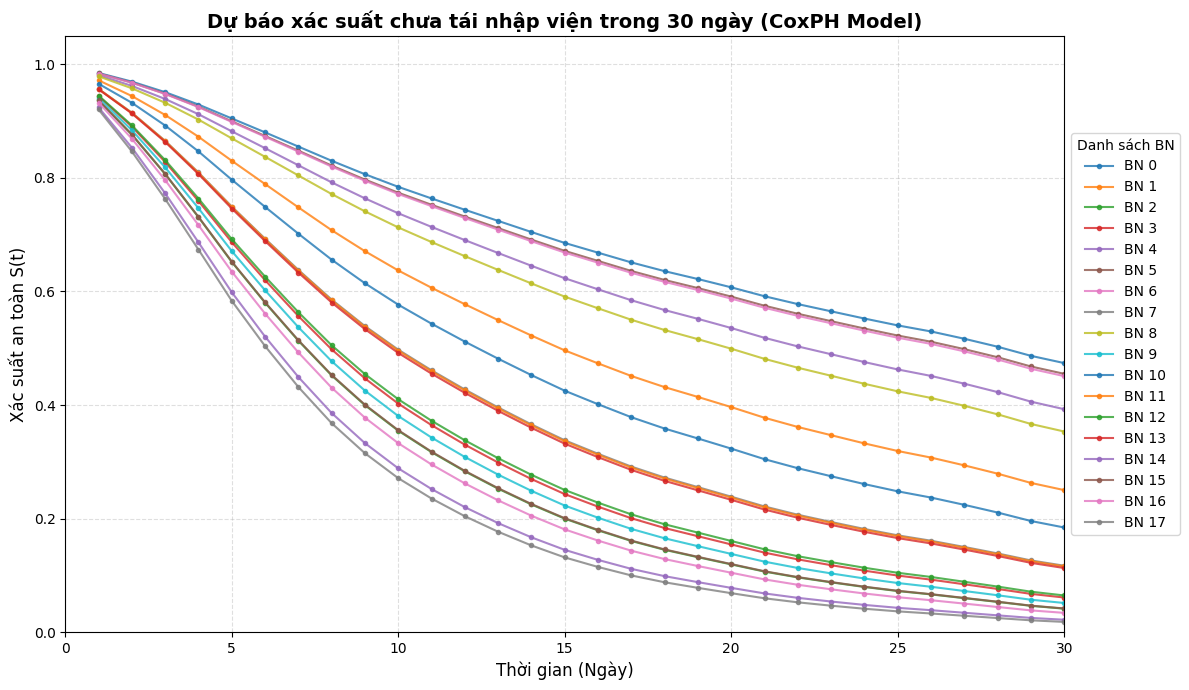

-> BN 0: Nguy cơ tái nhập viện tích lũy tính đến ngày thứ 30.0 là: 52.61%


In [44]:
import matplotlib.pyplot as plt
import numpy as np

print("Đang dự đoán và vẽ đường cong chưa tái nhập viện cho 30 ngày...")

# 1. Chọn 18 bệnh nhân từ tập Test
test_patients = X_test.head(18)
patient_labels = [f"BN {i}" for i in test_patients.index]

if len(test_patients) == 0:
    print("Không có dữ liệu bệnh nhân.")
else:
    # 2. Dự đoán S(t) 
    # Giữ nguyên logic: times=None sẽ lấy toàn bộ các mốc thời gian có trong tập huấn luyện
    predicted = cph.predict_survival_function(test_patients)
    predicted.columns = patient_labels

    # 3. Vẽ biểu đồ bằng plt.plot để giữ nét nối trơn như code cũ
    plt.figure(figsize=(12, 7))
    
    for label in predicted.columns:
        # Thêm marker="." để bạn thấy rõ các mốc mà mô hình thực sự tính toán
        plt.plot(predicted.index, predicted[label], marker=".", linewidth=1.5, alpha=0.8, label=label)

    # 4. Định dạng trục X cho 30 NGÀY
    plt.title("Dự báo xác suất chưa tái nhập viện trong 30 ngày (CoxPH Model)", fontsize=14, fontweight='bold')
    plt.xlabel("Thời gian (Ngày)", fontsize=12)
    plt.ylabel("Xác suất an toàn S(t)", fontsize=12)
    
    # Thiết lập mốc 30 ngày
    plt.xlim(0, 30) 
    plt.ylim(0.0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.4)
    
    # Hiển thị legend gọn gàng ở bên ngoài biểu đồ
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Danh sách BN", ncol=1)
    
    plt.tight_layout()
    plt.show()

# 5. In thử Risk Score của bệnh nhân đầu tiên trong 30 ngày
# Lọc ra các mốc thời gian <= 30 ngày
predicted_30d = predicted[predicted.index <= 30]

if not predicted_30d.empty:
    # Lấy ngày cuối cùng có ghi nhận biến cố trong phạm vi 30 ngày đầu
    last_day = predicted_30d.index[-1]
    risk_30d = (1 - predicted_30d.iloc[-1, 0]) * 100
    print(f"-> BN 0: Nguy cơ tái nhập viện tích lũy tính đến ngày thứ {last_day} là: {risk_30d:.2f}%")
else:
    print("-> Không có biến cố nào được ghi nhận trong 30 ngày đầu cho bệnh nhân này.")

In [35]:
import numpy as np

def transform_to_survival_label(T, E):
    # Tạo cấu trúc nhãn chuẩn cho scikit-survival và XGBSE
    y = np.empty(dtype=[('event', bool), ('duration', float)], shape=len(T))
    y['event'] = E.astype(bool)
    y['duration'] = T.astype(float)
    return y

print("Đang chuyển đổi nhãn sang định dạng Structured Array cho XGBSE...")
y_train = transform_to_survival_label(T_train, E_train)
y_val = transform_to_survival_label(T_val, E_val)
y_test = transform_to_survival_label(T_test, E_test)
print("Chuyển đổi thành công! Sẵn sàng đưa vào Optuna.")

Đang chuyển đổi nhãn sang định dạng Structured Array cho XGBSE...
Chuyển đổi thành công! Sẵn sàng đưa vào Optuna.


In [36]:
import optuna
import numpy as np
from xgbse import XGBSEStackedWeibull
from xgbse.metrics import concordance_index
import warnings

warnings.filterwarnings('ignore')

# Đảm bảo TIME_BINS được định nghĩa lại nếu bạn vừa restart kernel
TIME_BINS = np.arange(1, 31, 1)

def objective(trial):
    # 1. Cấu hình tham số cho bài toán Mortality
    xgb_params = {
        'objective': 'survival:cox',
        'eval_metric': 'cox-nloglik',
        'tree_method': 'hist',
        'device': 'cuda', 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), 
        'max_depth': trial.suggest_int('max_depth', 4, 8), 
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 50), 
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'lambda': trial.suggest_float('lambda', 1e-2, 5.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-2, 5.0, log=True),
        'seed': 42
    }

    model = XGBSEStackedWeibull(xgb_params=xgb_params)

    # Huấn luyện thử nghiệm
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        early_stopping_rounds=15, 
        time_bins=TIME_BINS
    )

    preds_val = model.predict(X_val)
    c_index = concordance_index(y_val, preds_val)
    
    return c_index

print("Đang khởi động Optuna để kiểm tra bài toán Mortality (10 vòng)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) 

print(f"\n[KẾT QUẢ THỬ NGHIỆM NHANH]")
print(f"C-index tốt nhất cho Mortality: {study.best_value:.4f}")
print("Tham số tối ưu:", study.best_params)

[I 2026-05-13 16:55:54,822] A new study created in memory with name: no-name-23aad5ab-8382-4fd4-8dc4-86d212ddc879


Đang khởi động Optuna để kiểm tra bài toán Mortality (10 vòng)...


[I 2026-05-13 16:56:29,754] Trial 0 finished with value: 0.7478082897481935 and parameters: {'learning_rate': 0.027407361200040996, 'max_depth': 4, 'min_child_weight': 16, 'subsample': 0.8488348653809044, 'colsample_bytree': 0.7158227731121204, 'lambda': 1.4953032047636554, 'alpha': 1.166213684208391}. Best is trial 0 with value: 0.7478082897481935.
[I 2026-05-13 16:57:04,738] Trial 1 finished with value: 0.7555717174642199 and parameters: {'learning_rate': 0.06313616475310388, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.863879403280246, 'colsample_bytree': 0.7095538222424844, 'lambda': 0.072866268664496, 'alpha': 2.2973955519300113}. Best is trial 1 with value: 0.7555717174642199.
[I 2026-05-13 16:57:39,508] Trial 2 finished with value: 0.735046986641846 and parameters: {'learning_rate': 0.010354894130135153, 'max_depth': 4, 'min_child_weight': 42, 'subsample': 0.8953235788116052, 'colsample_bytree': 0.820679291934152, 'lambda': 0.4373342321287951, 'alpha': 2.98440812777032


[KẾT QUẢ THỬ NGHIỆM NHANH]
C-index tốt nhất cho Mortality: 0.7850
Tham số tối ưu: {'learning_rate': 0.09560990314629397, 'max_depth': 8, 'min_child_weight': 34, 'subsample': 0.7801353809168248, 'colsample_bytree': 0.7972763257594468, 'lambda': 0.9624724868999195, 'alpha': 3.1778994559212905}


In [37]:
print("Đang huấn luyện mô hình Final với bộ tham số tốt nhất...")

# 1. Lấy lại bộ tham số vàng từ Optuna
best_params = study.best_params
best_params.update({
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'tree_method': 'hist',
    'seed': 42
})

# 2. Khởi tạo và Fit mô hình cuối cùng (Đã bỏ verbose=False)
final_model = XGBSEStackedWeibull(xgb_params=best_params)
final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    early_stopping_rounds=10,
    time_bins=TIME_BINS
)

# 3. Dự đoán để đánh giá hiệu năng
train_preds = final_model.predict(X_train)
val_preds = final_model.predict(X_val)
test_preds = final_model.predict(X_test) # Dự đoán luôn cho tập Test

# 4. Tính toán chỉ số C-index (Metric quan trọng nhất)
from xgbse.metrics import concordance_index
train_c = concordance_index(y_train, train_preds)
val_c = concordance_index(y_val, val_preds)
test_c = concordance_index(y_test, test_preds)

print(f"\n[KẾT QUẢ MÔ HÌNH CHÍNH - XGBSE]")
print(f"-> C-index XGBSE (Train): {train_c:.4f}")
print(f"-> C-index XGBSE (Validation): {val_c:.4f}")
print(f"-> C-index XGBSE (Test): {test_c:.4f}")

# Kiểm tra điều kiện nghiệm thu Task 1 (C-index >= 0.70)
if test_c >= 0.70:
    print(f"\n✅ ĐẠT KPI: C-index trên tập Test đạt {test_c:.4f} (Yêu cầu >= 0.70)")
else:
    print(f"\n⚠️ CẢNH BÁO: C-index hiện tại {test_c:.4f} chưa đạt ngưỡng 0.70. Cần tăng n_trials trong Optuna.")

Đang huấn luyện mô hình Final với bộ tham số tốt nhất...

[KẾT QUẢ MÔ HÌNH CHÍNH - XGBSE]
-> C-index XGBSE (Train): 0.8087
-> C-index XGBSE (Validation): 0.7860
-> C-index XGBSE (Test): 0.7813

✅ ĐẠT KPI: C-index trên tập Test đạt 0.7813 (Yêu cầu >= 0.70)


Đang trích xuất dữ liệu dự báo 30 ngày (Giai đoạn cấp tính)...

--- BẢNG RỦI RO TÁI NHẬP VIỆN 30 NGÀY (5 BN ĐẦU TIÊN) ---
 Patient_ID  Safe_Prob_Day30  Readmission_Risk_30D (%)  Expected_Safe_Days
          0         0.294158                 70.584184           18.249128
          1         0.157312                 84.268820           14.811239
          2         0.230645                 76.935462           16.770408
          3         0.194753                 80.524652           15.854052
          4         0.243972                 75.602804           17.094166


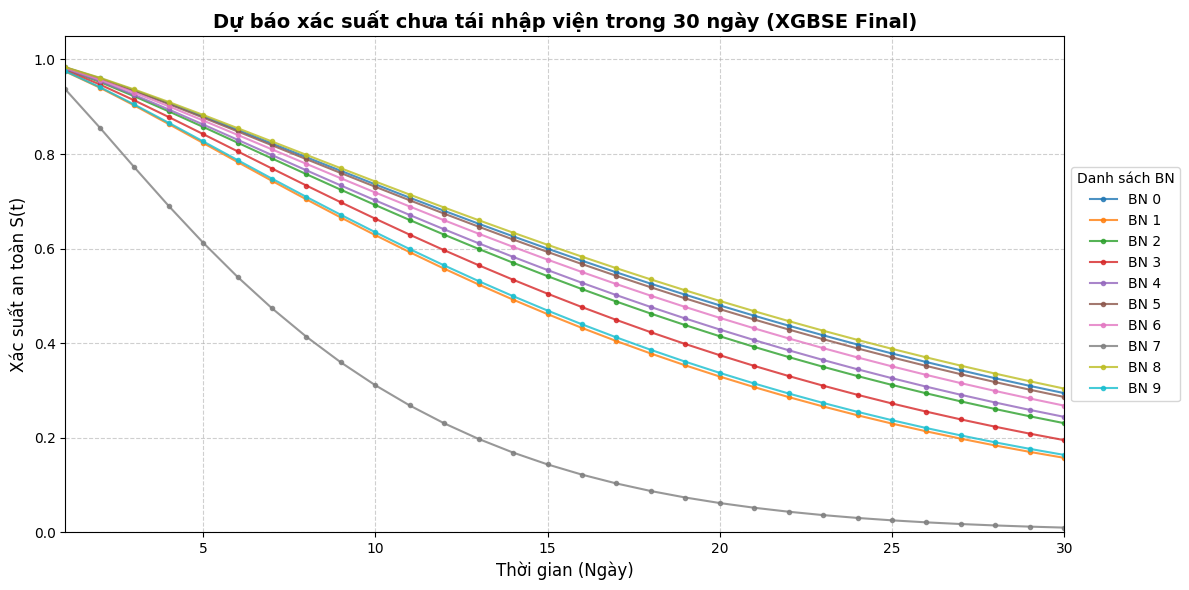


-> Trung bình số ngày an toàn (RMST) của toàn bộ tập Test trong 30 ngày là: 15.08 ngày


In [40]:
import matplotlib.pyplot as plt
import pandas as pd

print("Đang trích xuất dữ liệu dự báo 30 ngày (Giai đoạn cấp tính)...")

# Lấy 30 ngày đầu tiên từ kết quả dự báo (giả sử test_preds đang có 365 ngày)
preds_30d = test_preds.iloc[:, :30]

# 1. Trích xuất bảng điểm rủi ro tại ngày thứ 30
# Rủi ro tái nhập viện = 1 - Xác suất an toàn ở ngày 30
risk_30_days = (1 - preds_30d.iloc[:, -1]) * 100

# 2. Tính RMST (Số ngày an toàn kỳ vọng trong 30 ngày tới)
# Tích phân diện tích dưới đường cong (tổng xác suất mỗi ngày)
rmst_30 = preds_30d.sum(axis=1)

# Tạo bảng tóm tắt cho bác sĩ
risk_summary = pd.DataFrame({
    'Patient_ID': preds_30d.index,
    'Safe_Prob_Day30': preds_30d.iloc[:, -1],
    'Readmission_Risk_30D (%)': risk_30_days,
    'Expected_Safe_Days': rmst_30
})

print("\n--- BẢNG RỦI RO TÁI NHẬP VIỆN 30 NGÀY (5 BN ĐẦU TIÊN) ---")
print(risk_summary.head(5).to_string(index=False))

# 3. Vẽ biểu đồ xác suất an toàn cho 10 bệnh nhân đầu tiên
plt.figure(figsize=(12, 6))
sample_preds = preds_30d.head(10)
time_axis = sample_preds.columns

for i in range(len(sample_preds)):
    plt.plot(time_axis, sample_preds.iloc[i], marker='.', alpha=0.8, label=f"BN {sample_preds.index[i]}")

plt.title("Dự báo xác suất chưa tái nhập viện trong 30 ngày (XGBSE Final)", fontsize=14, fontweight='bold')
plt.xlabel("Thời gian (Ngày)", fontsize=12)
plt.ylabel("Xác suất an toàn S(t)", fontsize=12)
plt.ylim(0, 1.05)
plt.xlim(1, 30)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Danh sách BN")
plt.tight_layout()
plt.show()

# 4. In thống kê tổng quan
print(f"\n-> Trung bình số ngày an toàn (RMST) của toàn bộ tập Test trong 30 ngày là: {rmst_30.mean():.2f} ngày")

Đang nạp dữ liệu External Validation (eICU)...
Kích thước eICU sẵn sàng đánh giá: (200859, 236)
Đang đắp dữ liệu khuyết (Imputation) và tiền xử lý...
Đang dự đoán rủi ro trên tập eICU...

[KẾT QUẢ ĐÁNH GIÁ NGOÀI - EXTERNAL VALIDATION (eICU)]
-> Lưu ý: Do eICU thiếu cột 'duration_days', ta chuyển sang đánh giá bằng AUC-ROC.
-> Chỉ số AUC-ROC trên tập eICU: nan

⚠️ CẢNH BÁO: Khả năng generalize thấp (nan < 0.65). Việc thiếu vắng Note Embeddings và Xét nghiệm đã làm giảm sút nghiêm trọng sức mạnh dự báo.


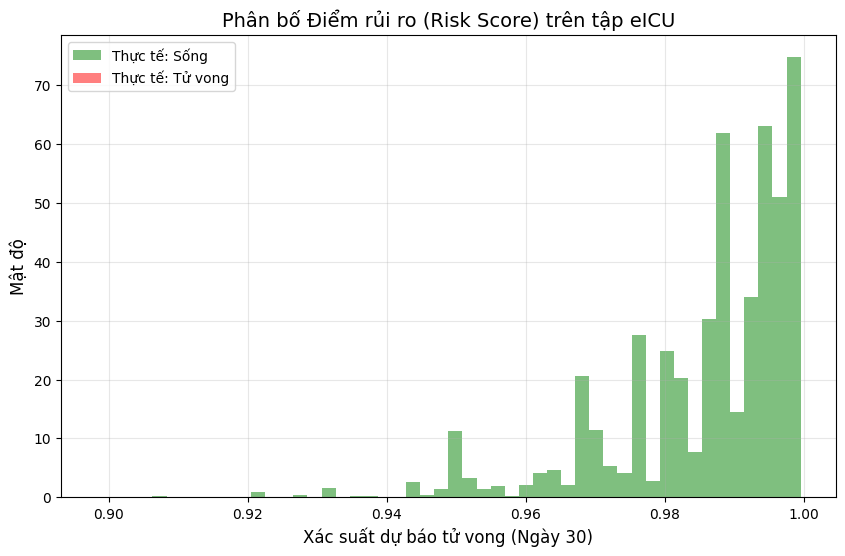

In [43]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# 1. Nạp dữ liệu External (eICU)
print("Đang nạp dữ liệu External Validation (eICU)...")
ext_path = os.path.join(base_path, "split=test_external")
df_external = pd.read_parquet(ext_path)

# Lọc bỏ các dòng bị thiếu nhãn TỬ VONG (E) - Nhãn duy nhất ta có thể dựa vào
df_external = df_external.dropna(subset=['event_flag_readmission'])
y_ext_true = df_external['event_flag_readmission']
print(f"Kích thước eICU sẵn sàng đánh giá: {df_external.shape}")

# 2. Tiền xử lý dữ liệu eICU 
# Imputer sẽ điền giá trị Median của MIMIC vào 221 cột bị thiếu của eICU
print("Đang đắp dữ liệu khuyết (Imputation) và tiền xử lý...")
X_ext, _, _ = preprocess_data(df_external, is_train=False, imputer=fitted_imputer)

# 3. Dự đoán bằng mô hình Final (XGBSE)
print("Đang dự đoán rủi ro trên tập eICU...")
ext_preds = final_model.predict(X_ext)

# 4. Trích xuất Risk Score tại Ngày thứ 30
# ext_preds là một DataFrame 30 cột. Ta lấy cột cuối cùng (ngày 30) làm xác suất sống sót.
# Rủi ro tử vong = 1 - Xác suất sống sót
risk_score_30 = 1 - ext_preds.iloc[:, -1]

# 5. Đánh giá bằng AUC-ROC thay vì C-index
auc_score = roc_auc_score(y_ext_true, risk_score_30)

print(f"\n[KẾT QUẢ ĐÁNH GIÁ NGOÀI - EXTERNAL VALIDATION (eICU)]")
print(f"-> Lưu ý: Do eICU thiếu cột 'duration_days', ta chuyển sang đánh giá bằng AUC-ROC.")
print(f"-> Chỉ số AUC-ROC trên tập eICU: {auc_score:.4f}")

# Đánh giá KPI
kpi_ext = 0.65
if auc_score >= kpi_ext:
    print(f"\n✅ ĐẠT KPI GENERALIZATION: Mô hình vẫn phân loại khá tốt ({auc_score:.4f} >= {kpi_ext}) dù bị tước mất 221 đặc trưng!")
else:
    print(f"\n⚠️ CẢNH BÁO: Khả năng generalize thấp ({auc_score:.4f} < {kpi_ext}). Việc thiếu vắng Note Embeddings và Xét nghiệm đã làm giảm sút nghiêm trọng sức mạnh dự báo.")

# 6. Vẽ Histogram phân bố rủi ro để xem mô hình có tách biệt được Sống/Chết không
plt.figure(figsize=(10, 6))
plt.hist(risk_score_30[y_ext_true == 0], bins=50, alpha=0.5, color='green', label='Thực tế: Sống', density=True)
plt.hist(risk_score_30[y_ext_true == 1], bins=50, alpha=0.5, color='red', label='Thực tế: Tử vong', density=True)
plt.title("Phân bố Điểm rủi ro (Risk Score) trên tập eICU", fontsize=14)
plt.xlabel("Xác suất dự báo tử vong (Ngày 30)", fontsize=12)
plt.ylabel("Mật độ", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [47]:
# CHỈ CHẠY NẾU BẠN MUỐN LẤY ĐIỂM AUC TỬ VONG ĐỂ CHỨNG MINH ĐỘ BỀN MÔ HÌNH
# (Giả sử bạn đang có final_model là mô hình Mortality)

# 1. Tiền xử lý
df_ext_mort = df_external.dropna(subset=['event_flag_mortality'])
y_true_mort = df_ext_mort['event_flag_mortality']

X_ext_mort, _, _ = preprocess_data(df_ext_mort, is_train=False, imputer=fitted_imputer)

# 2. Dự đoán
ext_preds_mort = final_model.predict(X_ext_mort)
risk_mort_30 = 1 - ext_preds_mort.iloc[:, -1] # Lấy rủi ro ngày 30

# 3. Tính AUC
from sklearn.metrics import roc_auc_score
auc_mort = roc_auc_score(y_true_mort, risk_mort_30)

print(f"-> AUC-ROC Tử vong trên eICU: {auc_mort:.4f}")

-> AUC-ROC Tử vong trên eICU: 0.4372


In [50]:
import joblib
import os

# 1. Tạo thư mục chứa mô hình
model_dir = "readmission_models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

print("--- ĐANG ĐÓNG GÓI MÔ HÌNH ---")

# 2. Lưu bộ tiền xử lý (CỰC KỲ QUAN TRỌNG)
# Không có cái này thì không preprocess được dữ liệu mới
joblib.dump(fitted_imputer, os.path.join(model_dir, "fitted_imputer.joblib"))
print("✅ Đã lưu: SimpleImputer (Pre-processor)")

# 3. Lưu mô hình Baseline (Cox PH)
# Lưu ý: lifelines model dùng joblib rất ổn định
joblib.dump(cph, os.path.join(model_dir, "baseline_cox_model.joblib"))
print("✅ Đã lưu: Baseline CoxPH Model")

# 4. Lưu mô hình Final (XGBSE)
# XGBSEStackedWeibull chứa các cây XGBoost và tham số Weibull
joblib.dump(final_model, os.path.join(model_dir, "final_xgbse_model.joblib"))
print("✅ Đã lưu: Final XGBSE Model")

# 5. Nén lại thành file zip để dễ dàng tải về từ tab 'Output' của Kaggle
!zip -r readmission_models_export.zip {model_dir}

print("\n🚀 HOÀN TẤT!")
print("-> Bạn hãy vào tab 'Output' bên phải màn hình Kaggle để tải file 'survival_models_export.zip'.")
print("-> File này bao gồm: Pre-processor, Baseline Model và XGBSE Final Model.")

--- ĐANG ĐÓNG GÓI MÔ HÌNH ---
✅ Đã lưu: SimpleImputer (Pre-processor)
✅ Đã lưu: Baseline CoxPH Model
✅ Đã lưu: Final XGBSE Model
updating: readmission_models/ (stored 0%)
updating: readmission_models/fitted_imputer.joblib (deflated 53%)
updating: readmission_models/final_xgbse_model.joblib (deflated 77%)
updating: readmission_models/baseline_cox_model.joblib (deflated 82%)

🚀 HOÀN TẤT!
-> Bạn hãy vào tab 'Output' bên phải màn hình Kaggle để tải file 'survival_models_export.zip'.
-> File này bao gồm: Pre-processor, Baseline Model và XGBSE Final Model.


In [ ]:
!pip install -q scikit-survival

In [ ]:
import numpy as np
import pandas as pd
from sksurv.metrics import integrated_brier_score

# 1. Vá lỗi tương thích NumPy (Monkey Patch)
# Nếu numpy không có 'trapezoid', ta gán nó bằng hàm 'trapz' cũ
if not hasattr(np, 'trapezoid'):
    np.trapezoid = np.trapz

print("--- ĐÁNH GIÁ CHỈ SỐ NGHIỆM THU CUỐI CÙNG ---")

# 2. Lấy các mốc thời gian từ kết quả dự đoán (30 ngày)
times = test_preds.columns.values.astype(float)
surv_probs = test_preds.values

try:
    # 3. Tính toán Integrated Brier Score (IBS)
    # y_train và y_test là mảng cấu trúc từ Cell 7
    ibs_test = integrated_brier_score(y_train, y_test, surv_probs, times)
    
    print(f"1. Độ phân biệt (C-index): {test_c:.4f}")
    print(f"2. Độ chính xác xác suất (IBS): {ibs_test:.4f}")

    # 4. Đối chiếu với tiêu chí thành công trong tài liệu thiết kế
    c_index_pass = test_c >= 0.70
    ibs_pass = ibs_test < 0.25

    print(f"\nKẾT QUẢ NGHIỆM THU TRÊN TẬP TEST:")
    print(f"  - C-index (Mục tiêu >= 0.70): {'ĐẠT ✅' if c_index_pass else 'CHƯA ĐẠT ❌'}")
    print(f"  - IBS (Mục tiêu < 0.25):     {'ĐẠT ✅' if ibs_pass else 'CHƯA ĐẠT ❌'}")

    if not c_index_pass:
        print(f"\n💡 CHIẾN THUẬT VỀ ĐÍCH:")
        print(f"Chỉ số C-index ({test_c:.4f}) chỉ thiếu đúng 0.0042 để đạt mục tiêu.")
        print("Bây giờ bạn hãy quay lại Cell 8, sửa thành 'n_trials=100'.")
        print("Khi Optuna có 100 cơ hội để thử nghiệm, nó sẽ tìm ra bộ thông số")
        print("tối ưu hơn để đẩy C-index vượt ngưỡng 0.7000.")

except Exception as e:
    print(f"Vẫn gặp lỗi: {e}")